------
## Wstęp do Eksploracji Danych
### Laboratorium 14
------

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 0. Zadania rozgrzewkowe

#### **Analiza zachowań klientów i przychodów sklepu internetowego z elektroniką**
------

Wyobraźmy sobie zbiór danych dotyczący zamówień w sklepie internetowym w ciągu ostatniego roku. Każdy rekord to jedno zamówienie.

Kolumny w zbiorze danych:

`Data` – data zakupu.

`Kategoria` – kategoria produktu (Smartfony, Laptopy, Akcesoria, Audio).

`Wiek_Klienta` – wiek osoby dokonującej zakupu.

`Wartosc_Zamowienia` – kwota w PLN.

`Typ_Urzadzenia` – urządzenie, na którym dokonano zakupu (Mobile, Desktop).

`Ocena_Produktu` – ocena wystawiona przez klienta (od 1 do 5).

In [2]:
df = pd.read_csv("../lab13/dane_sprzedaz.csv")

In [3]:
df

,Data,Kategoria,Wiek_Klienta,Wartosc_Zamowienia,Typ_Urzadzenia,Ocena_Produktu
0,2025-04-13,Akcesoria,57,167.700,Desktop,3
1,2025-12-15,Smartfony,20,2712.024,Mobile,5
2,2025-09-28,Laptopy,43,3412.630,Mobile,5
3,2025-04-17,Smartfony,18,1961.330,Mobile,5
4,2025-03-13,Smartfony,18,1976.150,Mobile,5
...,...,...,...,...,...,...
995,2025-02-07,Smartfony,31,2213.360,Mobile,5
996,2025-10-20,Smartfony,18,3188.170,Desktop,1
997,2025-05-19,Smartfony,18,1953.130,Mobile,5
998,2025-12-22,Audio,57,1023.246,Desktop,1


### Zadanie 0.1
-----

Sprwadź poniższą hipotezę.

*Smartfony i laptopy generują największy całkowity przychód w sklepie.*

In [4]:
tabela_1 = df.groupby('Kategoria')['Wartosc_Zamowienia'].sum().reset_index()
tabela_1 = tabela_1.sort_values(by = "Wartosc_Zamowienia", ascending=False)
tabela_1

,Kategoria,Wartosc_Zamowienia
2,Laptopy,823222.012
3,Smartfony,802715.494
1,Audio,107941.010
0,Akcesoria,57067.338


Text(0.5, 1.0, 'Przychód w podziale na kategorie')

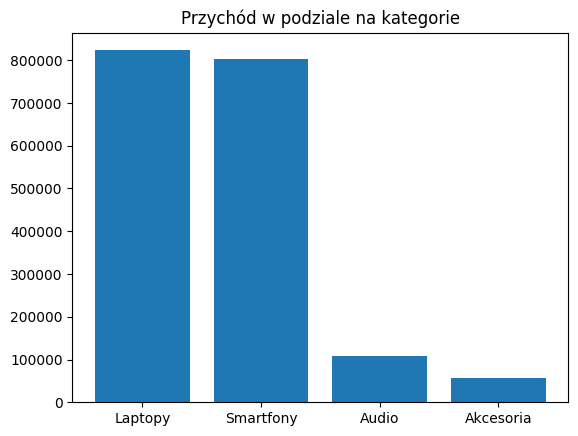

In [6]:
plt.bar(tabela_1['Kategoria'], tabela_1['Wartosc_Zamowienia'])
plt.title("Przychód w podziale na kategorie")

### Zadanie 0.2
-----

Sprwadź poniższą hipotezę.

*Starsi klienci średnio zostawiają w sklepie więcej pieniędzy niż młodsi.*

In [7]:
bins = [0, 25, 40, 55, 100]
labels = ["<25", "25-40", "41-55", '55+']

In [8]:
df['Grupa_Wiekowa'] = pd.cut(df['Wiek_Klienta'], bins=bins, labels=labels)

In [11]:
tabela_2 = df.groupby('Grupa_Wiekowa', observed=False)['Wartosc_Zamowienia'].agg("mean").to_frame().reset_index()
tabela_2

,Grupa_Wiekowa,Wartosc_Zamowienia
0,<25,1826.169576
1,25-40,1902.481066
2,41-55,1808.503687
3,55+,750.408456


Text(0.5, 1.0, 'Średnia wartość zamówienia w podziale na grupy wiekowe')

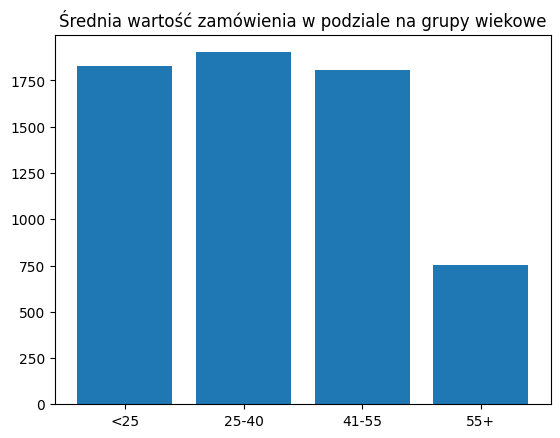

In [14]:
plt.bar(tabela_2['Grupa_Wiekowa'], tabela_2['Wartosc_Zamowienia'])
plt.title('Średnia wartość zamówienia w podziale na grupy wiekowe')

## `matplotlib` - poziom zaawansowany

## Konfiguracja `matplotlib`

**Jak dostosować właściwości i domyślny wygląd wykresów?**
- ustawiając `rcParams` (*runtime configuration parameters*),
- używając predefiniowanych stylów,
- tworząc/modyfikując plik `matplotlibrc` (*matplotlib runtime configuration*).

**Po co to robić?** 

- dla spójnego i jednolitego wyglądu wykresów:
    - w projekcie (raport, prezentacja, praca dyplomowa, ...),
    - w firmie (np. z wykorzystaniem szablonów, w zgodzie z identyfikacją wizualną);
- dla skrócenia czasu tworzenia wykresów i kodu potrzebnego do ich modyfikacji. 


In [15]:
import matplotlib.pyplot as plt
import matplotlib as mpl

### edytowanie `rcParams`

In [16]:
mpl.rcParams # słownik z aktualnymi ustawieniami

RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'both',
   

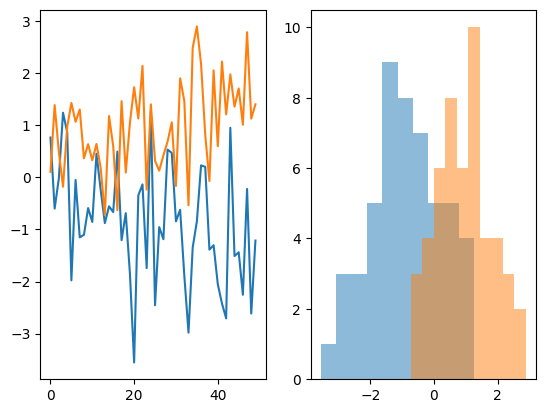

In [17]:
# domyślny wykres
np.random.seed(0)
data1 = np.random.normal(loc=-1, size=50)
data2 = np.random.normal(loc=1, size=50)

def example_plot():
    fig, axs = plt.subplots(1, 2)
    axs[0].plot(data1)
    axs[0].plot(data2)
    axs[1].hist(data1, alpha=0.5)
    axs[1].hist(data2, alpha=0.5)
    plt.show()

example_plot()

#### zmiana domyślnego rozmiaru wykresu i czcionki
(często przydatne do raportu lub prezentacji)

In [18]:
print(mpl.rcParams["figure.figsize"])
print(mpl.rcParams["font.size"])

[6.4, 4.8]
10.0


In [19]:
mpl.rcParams["figure.figsize"] = (12, 6)
mpl.rcParams["font.size"] = 15

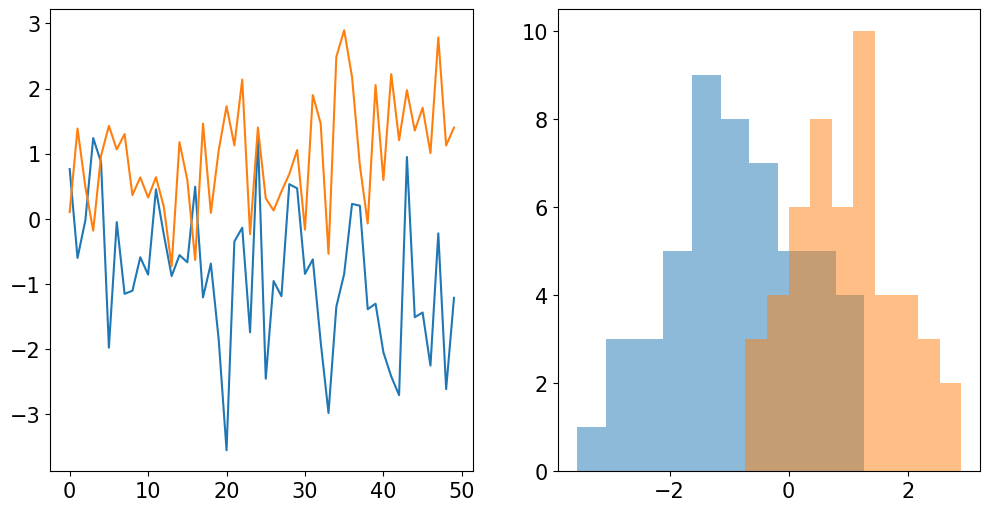

In [20]:
example_plot()

#### zmiana sekwencji kolorów 

In [21]:
mpl.rcParams["axes.prop_cycle"] # domyślny cykl kolorów

'#1f77b4'
'#ff7f0e'
'#2ca02c'
'#d62728'
'#9467bd'
'#8c564b'
'#e377c2'
'#7f7f7f'
'#bcbd22'
'#17becf'


In [22]:
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=["darkviolet", "forestgreen"]) # interesująca nas paleta kolorów

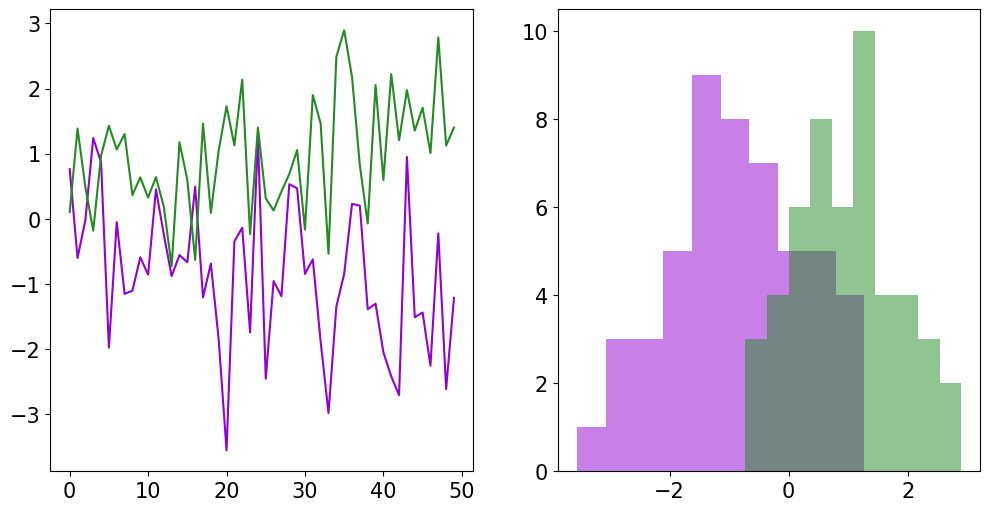

In [23]:
# wykres z nowymi ustawieniami
example_plot()

#### zmiana stylu konkretnej grupy elementów 
np. linii, markerów, siatki, ...

In [24]:
# linie
mpl.rcParams["lines.linewidth"] = 4
mpl.rcParams["lines.linestyle"] = "--"

# biny histogramu
mpl.rcParams["hist.bins"] = 6

# słupki (patch)
mpl.rcParams["patch.force_edgecolor"] = True  

# siatka na wykresie
mpl.rcParams["axes.grid"] = True  # żeby była siatka na wykresie
mpl.rcParams["axes.axisbelow"] = True  # żeby siatka była pod wykresem (domyślnie jest tylko pod liniami, ale nie pod punktami/słupkami)

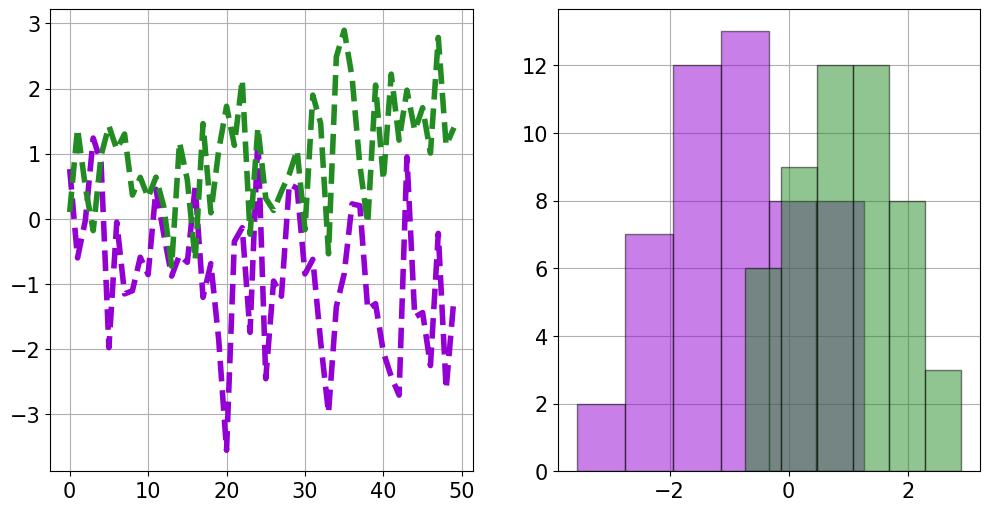

In [25]:
# wykres z nowymi ustawieniami
example_plot()

In [26]:
# parametry w obrębie jednej grupy można też zmieniać tak:
mpl.rc("lines", linewidth=1, linestyle="-.")

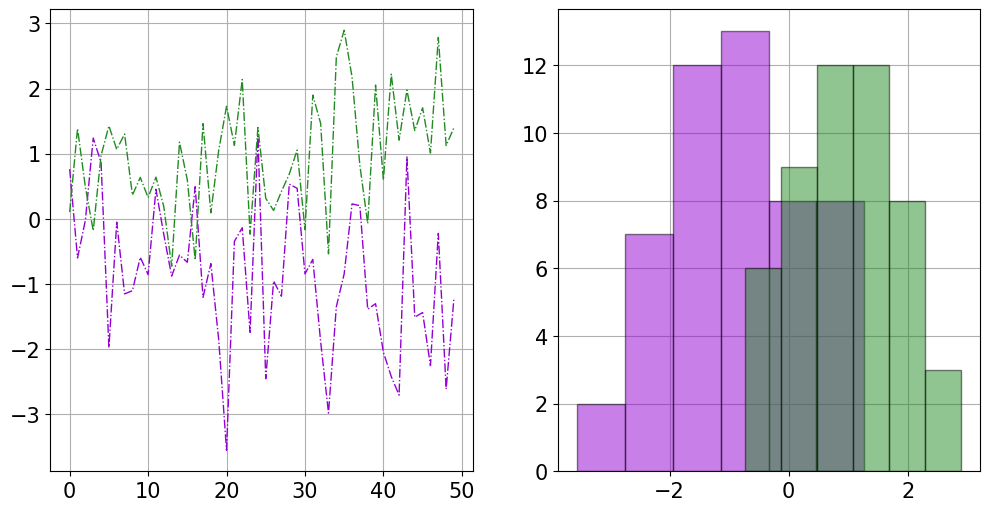

In [27]:
example_plot()

#### powrót do domyślnych ustawień

In [28]:
plt.rcdefaults()

### gotowe style
https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html

In [29]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [30]:
plt.style.use("ggplot")

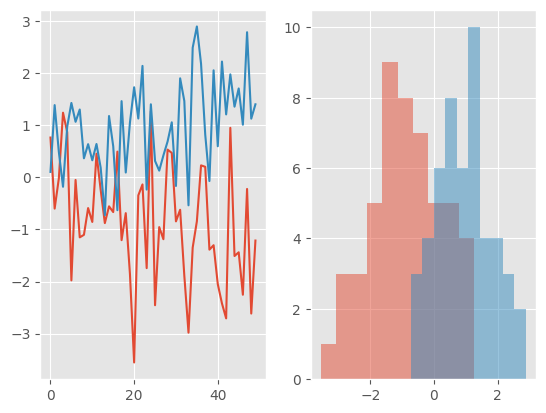

In [31]:
example_plot()

In [32]:
plt.style.use("dark_background")

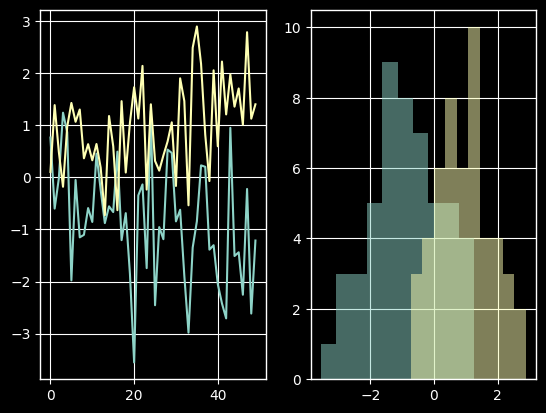

In [33]:
example_plot()

In [34]:
plt.rcdefaults()

## `matplotlib` - przydatne wskazówki

![](https://matplotlib.org/cheatsheets/_images/cheatsheets-1.png)

### złożone, dwuwymiarowe `subplots`
- spłaszczenie `axes` - `ax.flatten()`
- `plt.tight_layout()` w przypadku problemów z nachodzeniem się elementów
- `ax.set_facecolor()` w celu wyróżnienia jednego z wykresów

In [35]:
mu = np.linspace(-4, 4, 9)
mu 

array([-4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.])

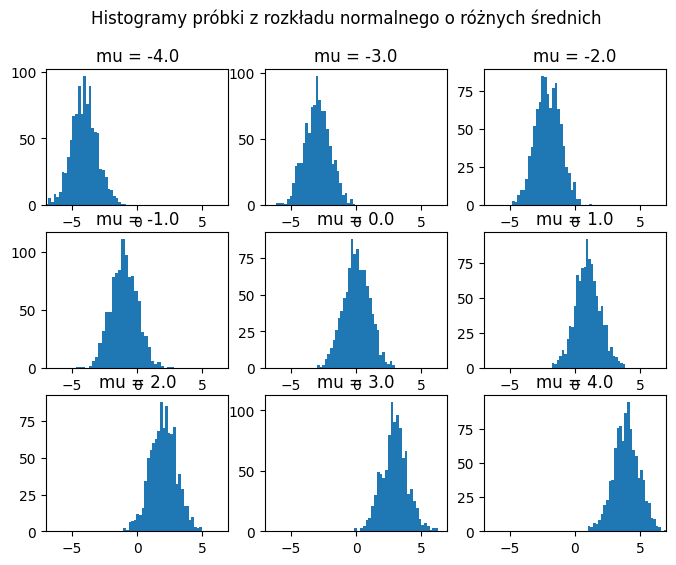

In [36]:
# przed
fig, axs = plt.subplots(3, 3, figsize=(8, 6))
for i in range(3):
    for j in range(3):
        index = 3*i + j # :( 
        axs[i, j].hist(np.random.normal(loc=mu[index], size=1000), bins=30)
        axs[i, j].set_xlim(-7, 7)
        axs[i, j].set_title(f"mu = {mu[index]}")
plt.suptitle("Histogramy próbki z rozkładu normalnego o różnych średnich")
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
C:\Users\AnnA\AppData\Local\Temp\ipykernel_38308\878107039.py:7: SyntaxWarning: invalid escape sequence '\m'
  axs[i].set_title(f"$\mu$ = {mu[i]}") # użycie TeXa


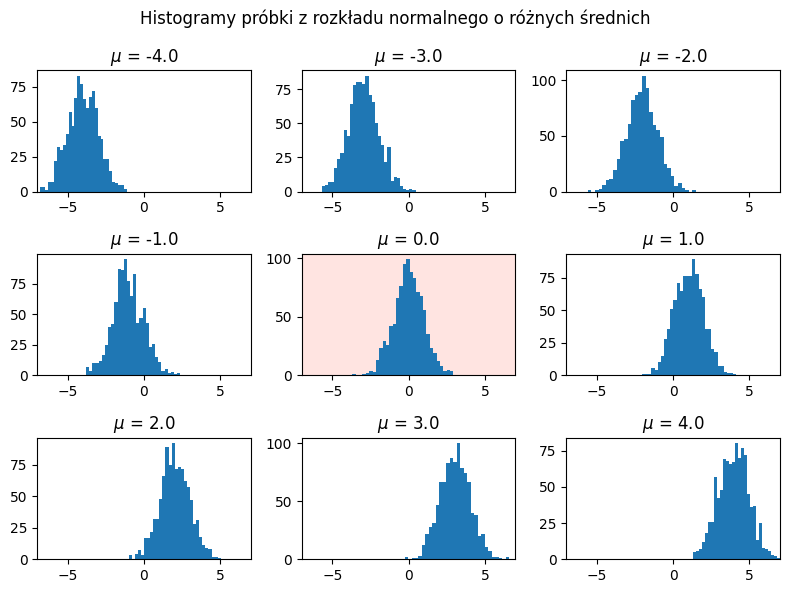

In [37]:
# po
fig, axs = plt.subplots(3, 3, figsize=(8, 6))
axs = axs.flatten()  # żeby nie trzeba było odwoływać się do dwuwymiarowej tablicy
for i in range(len(axs)):
    axs[i].hist(np.random.normal(loc=mu[i], size=1000), bins=30)
    axs[i].set_xlim(-7, 7)
    axs[i].set_title(f"$\mu$ = {mu[i]}") # użycie TeXa
axs[4].set_facecolor("mistyrose")  # zmiana koloru tła
plt.suptitle("Histogramy próbki z rozkładu normalnego o różnych średnich")
plt.tight_layout()  # żeby się nie nakładały
plt.show()

### dodawanie anotacji, edycja podpisów osi, ... 

In [38]:
x = np.linspace(0, 12 * np.pi, 1000)
y = np.sin(x)

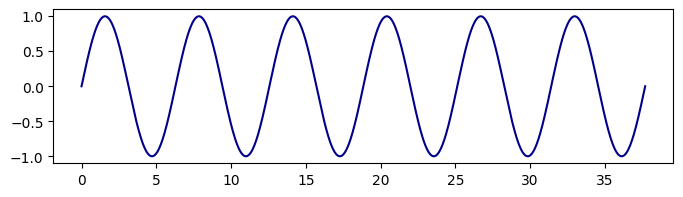

In [39]:
# podstawowy wykres
fig, ax = plt.subplots(1, 1, figsize=(8, 2))
ax.plot(x, y, color="darkblue")
plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\p'
C:\Users\AnnA\AppData\Local\Temp\ipykernel_38308\713237822.py:16: SyntaxWarning: invalid escape sequence '\p'
  mpl.ticker.FuncFormatter(lambda val, pos: f"${val / np.pi:.0f}\pi$")


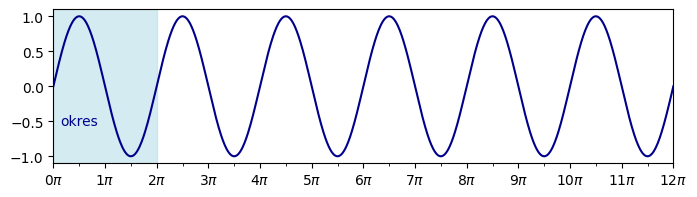

In [40]:
# poprawiony wykres
fig, ax = plt.subplots(1, 1, figsize=(8, 2))
ax.plot(x, y, color="darkblue")

# zacieniowanie obszaru, dodanie anotacji
ax.fill_betweenx([-1.1, 1.1], 0, 2 * np.pi, alpha=0.5, color="lightblue")
ax.text(np.pi / 2, -0.5, "okres", ha="center", va="center", color="darkblue")

# usunięcie białych marginesów przez zmianę granic osi
ax.set_xlim(0, 12 * np.pi)
ax.set_ylim(-1.1, 1.1)

# poprawa podpisów na osi x
ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(base=np.pi))  # ustawienie podziałki co pi
ax.xaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda val, pos: f"${val / np.pi:.0f}\pi$")
)  # użycie TeXa do wyświetlania symbolu pi
# matplotlib.ticker.FuncFormatter -- funkcja powinna przyjmować wartość i pozycję, a zwracać stringa do wyświetlenia
ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(n=2))  # podziałka co pi/2

plt.show()

### zapisywanie wykresów do pliku

**Przydatne argumenty:**
- `dpi` - dots per inch (rozdzielczość)
- `bbox_inches` - określa obszar, który ma być zapisany do pliku
- `transparent` - czy tło ma być przezroczyste


**O formatach:**
- Do raportów (w szczególności robionych w LaTeX-u) najlepiej zapisywać wykresy jako grafikę wektorową (np. `pdf` lub `svg`). Można wtedy wykorzystać np. Inkscape do dalszej edycji. 
- Jeśli konieczny jest format rastrowy, to lepiej użyć `png` niż `jpg` (lepsza jakość, wspiera przezroczystość).
- Do raportów w LaTeX-u można też użyć `pgf` (grafiki wektorowe z kodu) - wtedy wykresy są generowane przez LaTeX-a. Wymaga to zainstalowania dodatkowych pakietów, ale pozwala na zachowanie spójności czcionek i wyglądu wykresów z tekstem w dokumencie, a także na wykorzystanie na figurach LaTeX-owych poleceń (np. referencji do innego obiektu w dokumencie).

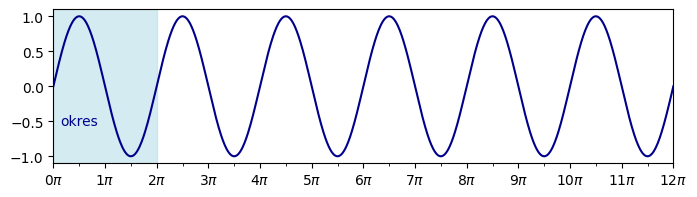

In [41]:
fig

In [ ]:
fig.savefig("wykres1.png") 

In [42]:
fig.savefig("wykres2.png", dpi=500, bbox_inches="tight") 

In [43]:
fig.savefig("wykres3.png", dpi=500, bbox_inches="tight", transparent=True)

In [ ]:
fig.savefig("wykres.pgf", bbox_inches="tight") # zapis do PGF

## `seaborn`: statistical data visualization

In [5]:
import seaborn as sns

In [6]:
sns.set_theme(rc = {'figure.figsize': (12,7)}) # nowy domyślny rozmiar wykresów
sns.set_style("darkgrid") # styl "darkgrid" tworzy jasnoszare tło z białymi liniami siatki
pd.options.display.max_rows = 10 # w ramce danych zostanie wyświetlone tylko 5 pierwszych i 5 ostatnich wierszy
pd.set_option('display.width', 5000) # maksymalna szerokość obszaru roboczego (w znakach), na którym Pandas może rysować tabelę
pd.set_option('display.max_columns', 60) # maksymalna liczbę kolumn, które zostanie pokazana na ekranie

In [7]:
df = pd.read_csv("https://raw.githubusercontent.com/kozaka93/2026L-ExploratoryDataAnalysis/refs/heads/main/labs/lab08/Pokemon.csv", sep=",")
df = df.drop(["#"], axis=1)

In [8]:
df

,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Stage,Legendary
0,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,2,False
2,Venusaur,Grass,Poison,525,80,82,83,100,100,80,3,False
3,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
4,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...
146,Dratini,Dragon,NaN,300,41,64,45,50,50,50,1,False
147,Dragonair,Dragon,NaN,420,61,84,65,70,70,70,2,False
148,Dragonite,Dragon,Flying,600,91,134,95,100,100,80,3,False
149,Mewtwo,Psychic,NaN,680,106,110,90,154,90,130,1,True


## wykres punktowy 

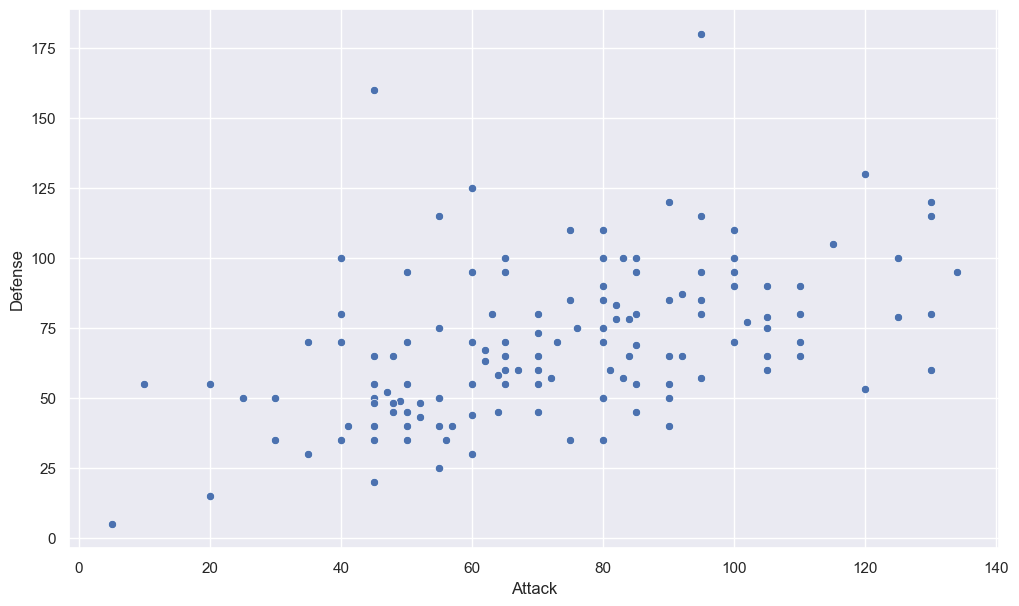

In [9]:
sns.scatterplot(data=df, x='Attack', y='Defense')
plt.show()

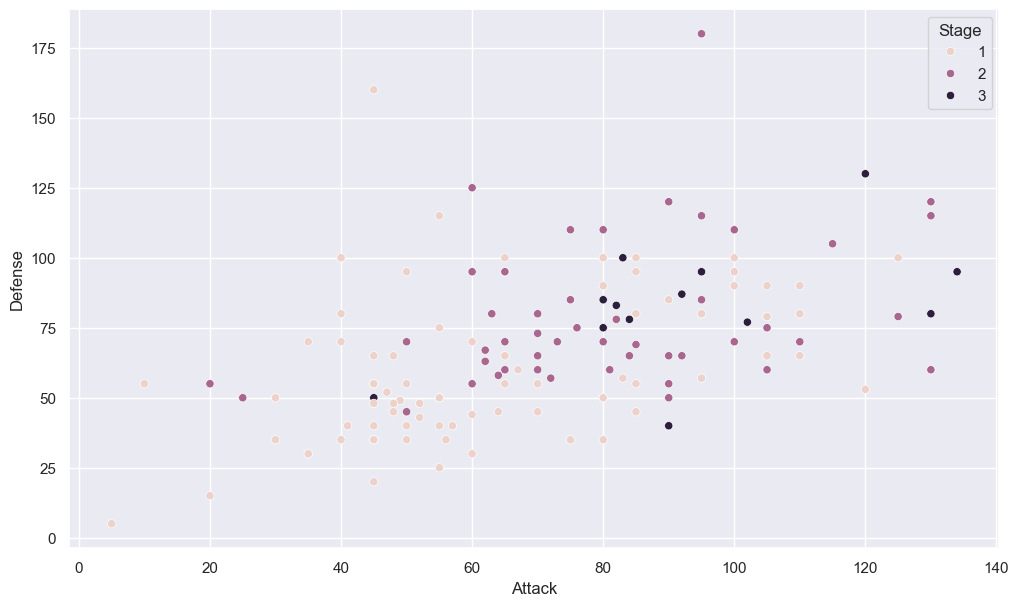

In [41]:
sns.scatterplot(data=df, x='Attack', y='Defense', hue='Stage')
plt.show()

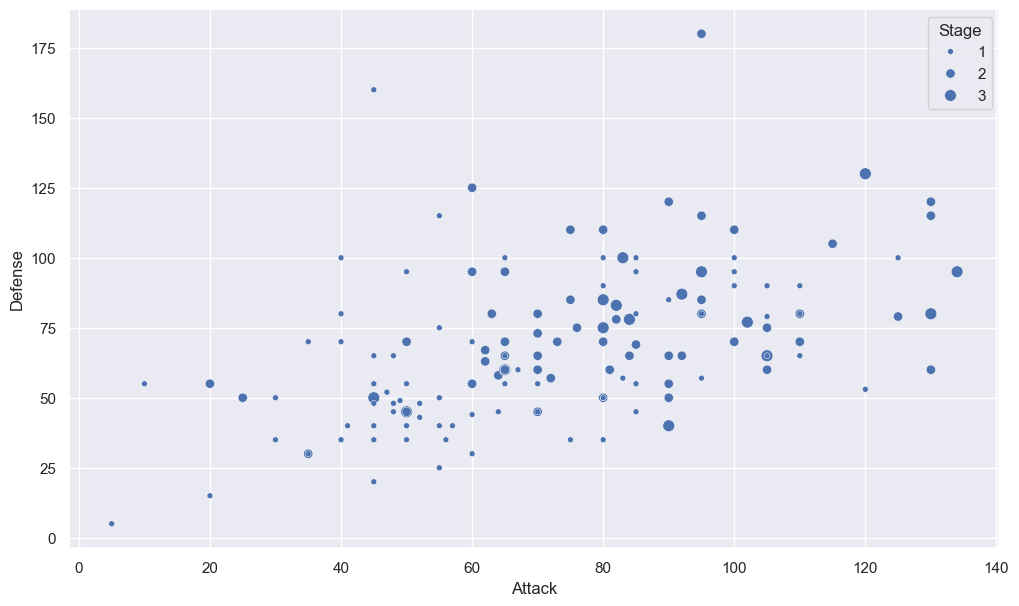

In [42]:
sns.scatterplot(data=df, x='Attack', y='Defense', size='Stage')
plt.show()

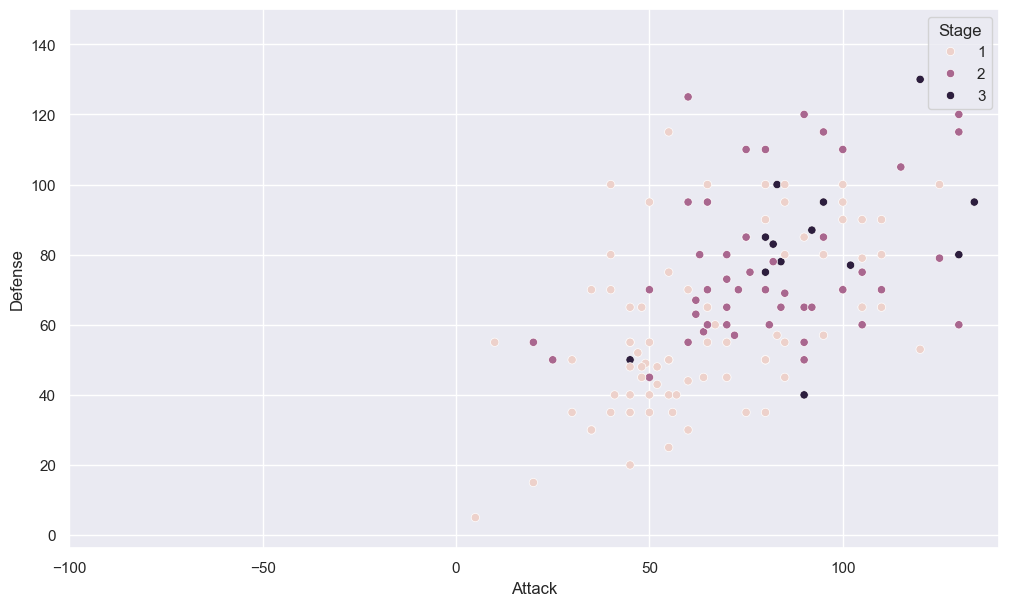

In [10]:
sns.scatterplot(data=df, x='Attack', y='Defense', hue='Stage')

plt.ylim(None, 150)
plt.xlim(-100, None)
plt.show()

## boxplot

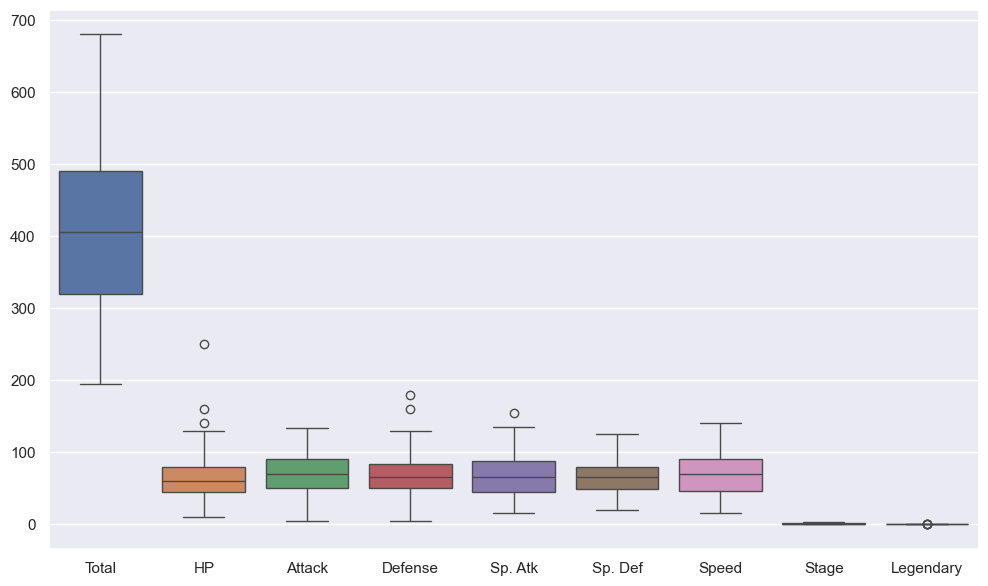

In [45]:
sns.boxplot(data=df)
plt.show()

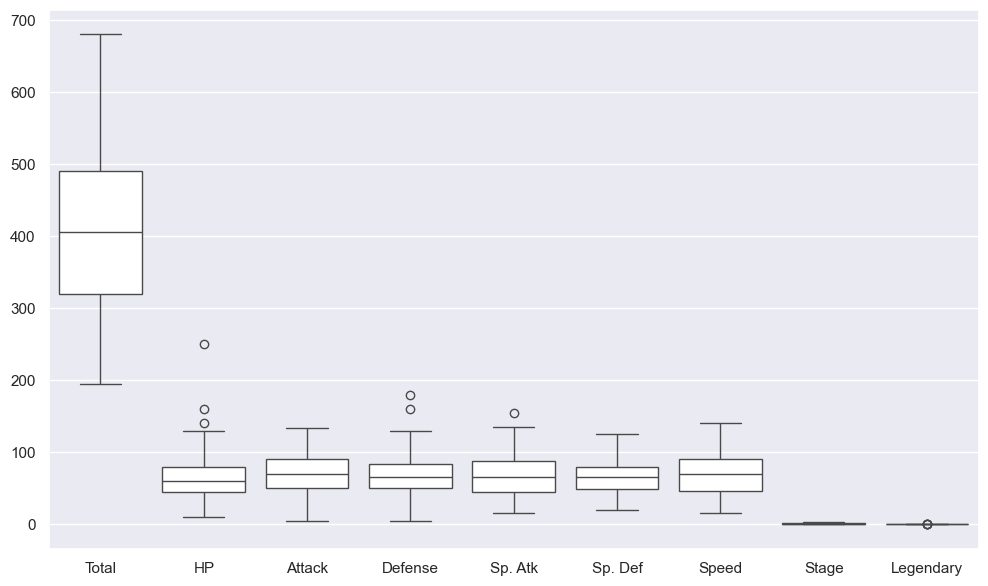

In [46]:
sns.boxplot(data=df, color='w')
plt.show()

In [11]:
stats_df = df.drop(['Total', 'Stage', 'Legendary'], axis=1)

<Axes: >

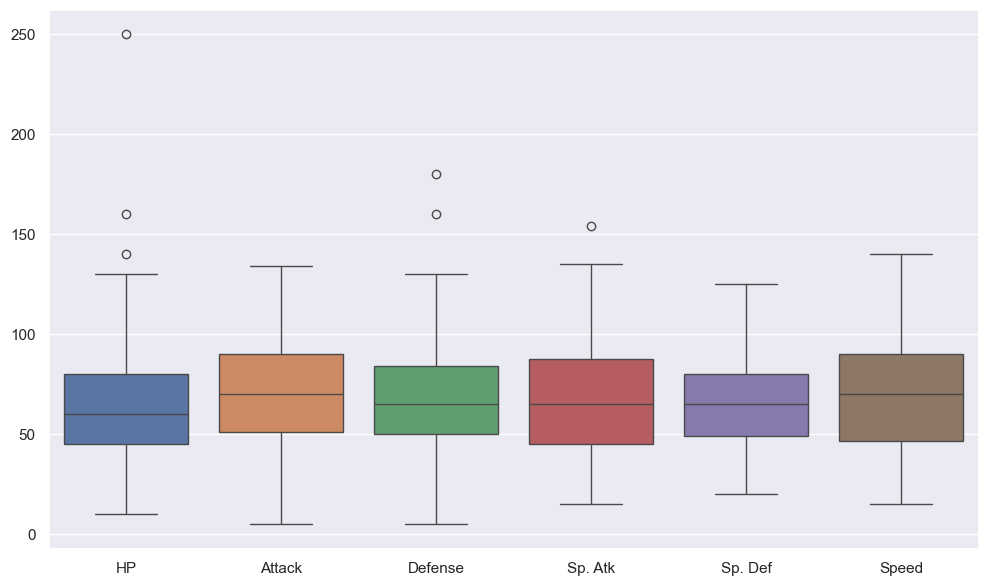

In [12]:
sns.boxplot(data=stats_df)

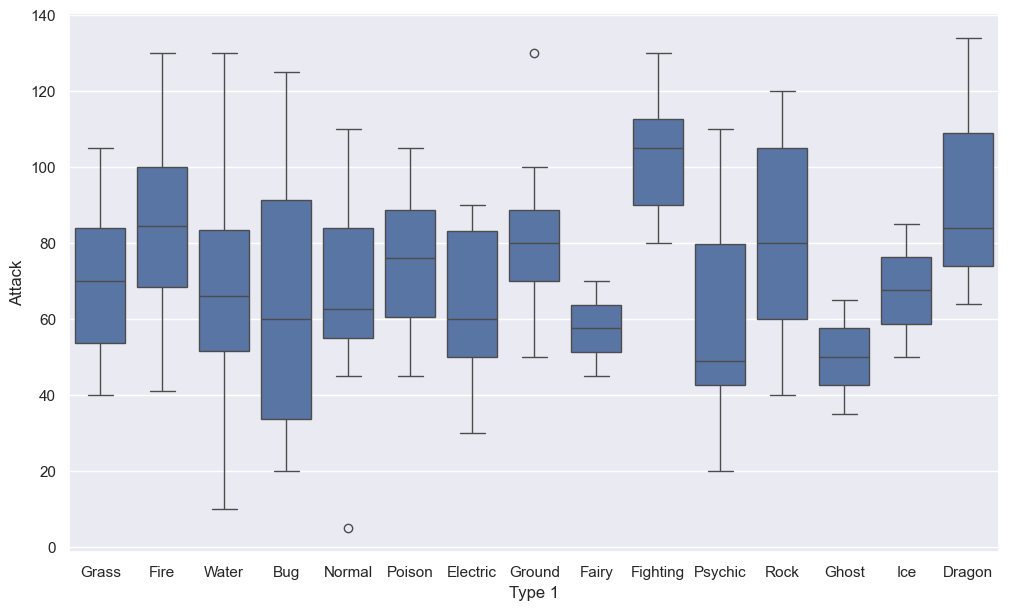

In [49]:
sns.boxplot(data=stats_df, x = 'Type 1', y = 'Attack')
plt.show()

## violin plot 

<Axes: xlabel='Type 1', ylabel='Attack'>

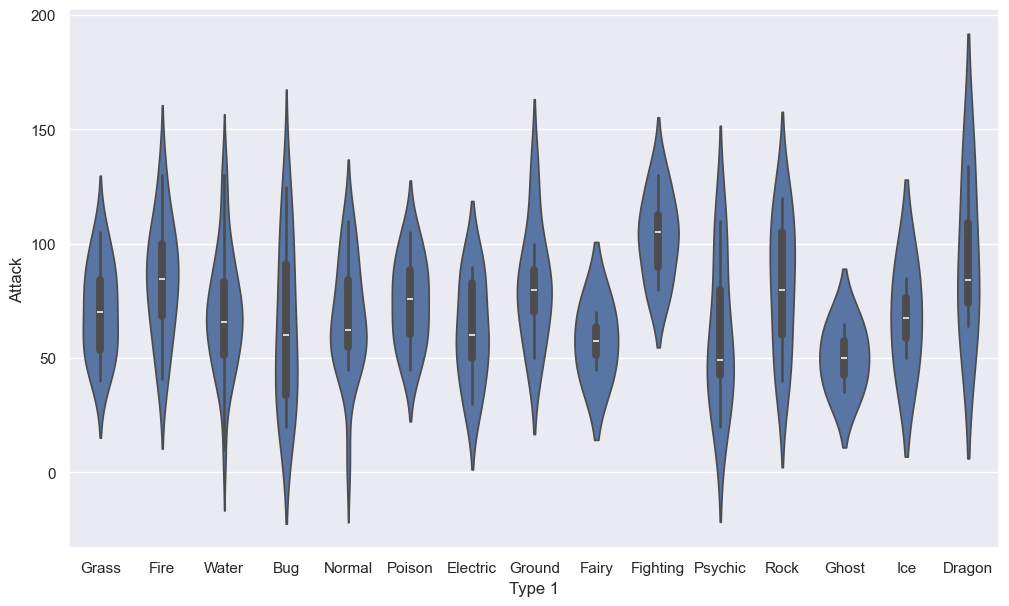

In [50]:
sns.violinplot(x = 'Type 1', y = 'Attack', data=df)

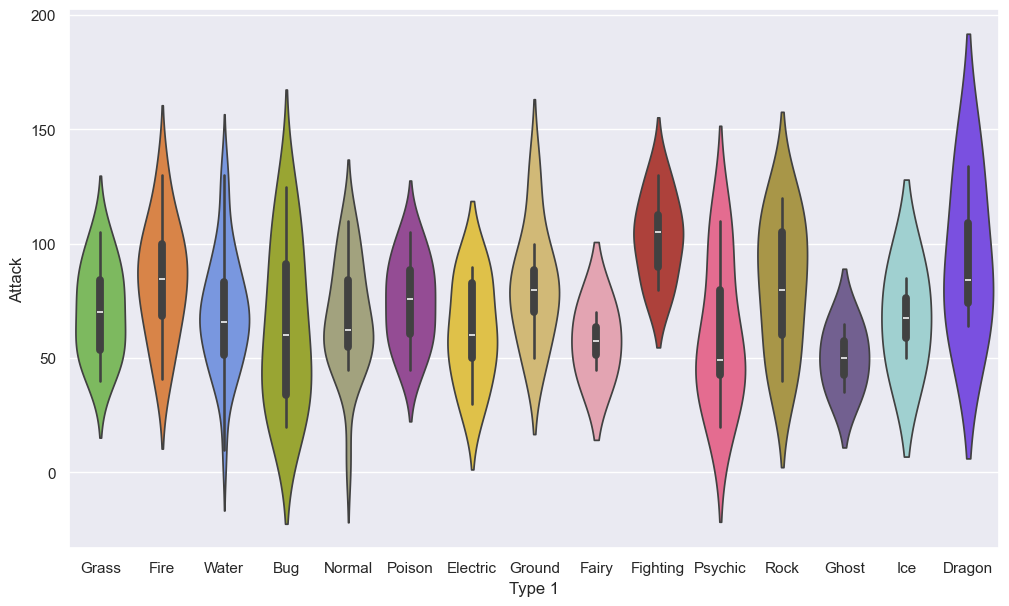

In [13]:
pkmn_type_colors = ['#78C850',  # Grass
                    '#F08030',  # Fire
                    '#6890F0',  # Water
                    '#A8B820',  # Bug
                    '#A8A878',  # Normal
                    '#A040A0',  # Poison
                    '#F8D030',  # Electric
                    '#E0C068',  # Ground
                    '#EE99AC',  # Fairy
                    '#C03028',  # Fighting
                    '#F85888',  # Psychic
                    '#B8A038',  # Rock
                    '#705898',  # Ghost
                    '#98D8D8',  # Ice
                    '#7038F8',  # Dragon
                   ]

sns.violinplot(x='Type 1', y='Attack', data=df, 
               hue='Type 1', legend=False,
               palette=pkmn_type_colors)
plt.show()



## swarm plot

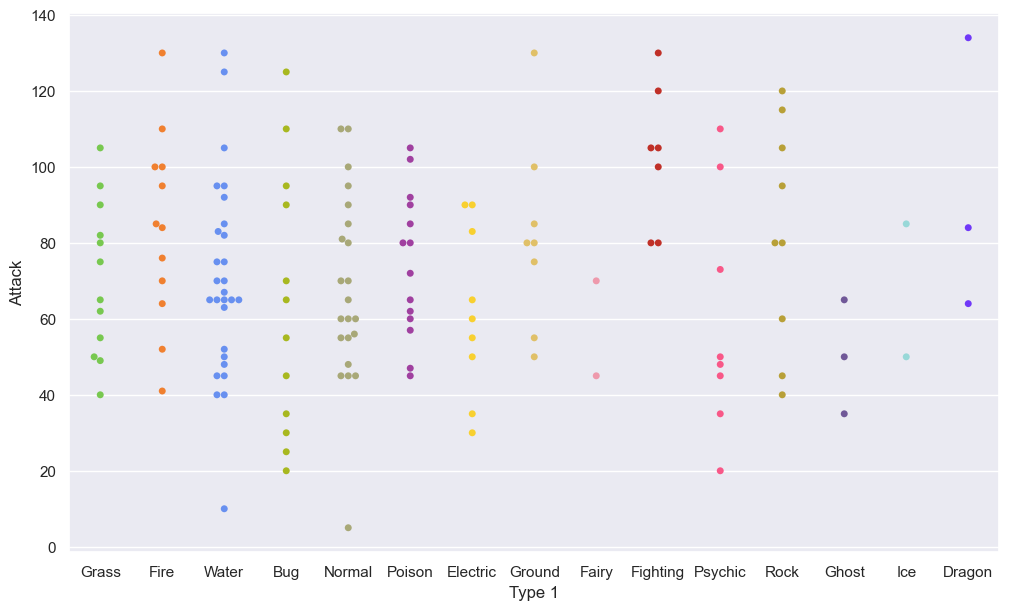

In [14]:
sns.swarmplot(x='Type 1', y='Attack', data=df, 
              hue='Type 1', legend=False,
              palette=pkmn_type_colors)
plt.show()

## nakładanie wykresów

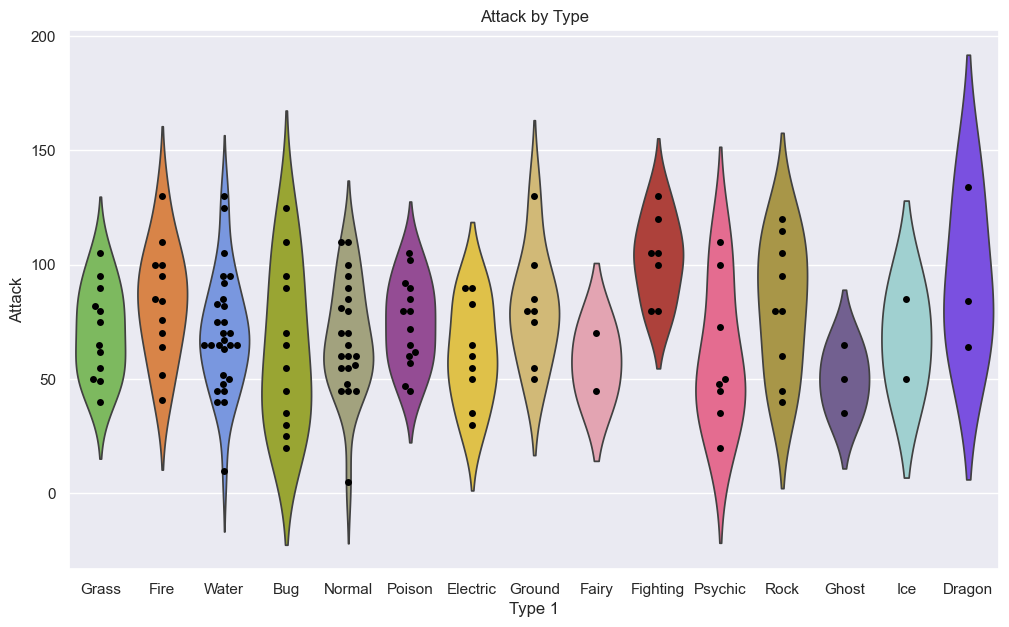

In [15]:
sns.violinplot(x='Type 1',
               y='Attack', 
               data=df, 
               hue='Type 1', legend=False,
               inner=None, # usunięcie boxplotów ze środka
               palette=pkmn_type_colors)
 
sns.swarmplot(x='Type 1', 
              y='Attack', 
              data=df, 
              color='black')# czarne punkty
 
# Tytuł z matplotlib
plt.title('Attack by Type')
plt.show()

In [16]:
melted_df = pd.melt(stats_df, 
                    id_vars=["Name", "Type 1", "Type 2"], # Zmienne do zatrzymania
                    var_name="Stat") # Nazwa nowej zmiennej
melted_df

,Name,Type 1,Type 2,Stat,value
0,Bulbasaur,Grass,Poison,HP,45
1,Ivysaur,Grass,Poison,HP,60
2,Venusaur,Grass,Poison,HP,80
3,Charmander,Fire,NaN,HP,39
4,Charmeleon,Fire,NaN,HP,58
...,...,...,...,...,...
901,Dratini,Dragon,NaN,Speed,50
902,Dragonair,Dragon,NaN,Speed,70
903,Dragonite,Dragon,Flying,Speed,80
904,Mewtwo,Psychic,NaN,Speed,130


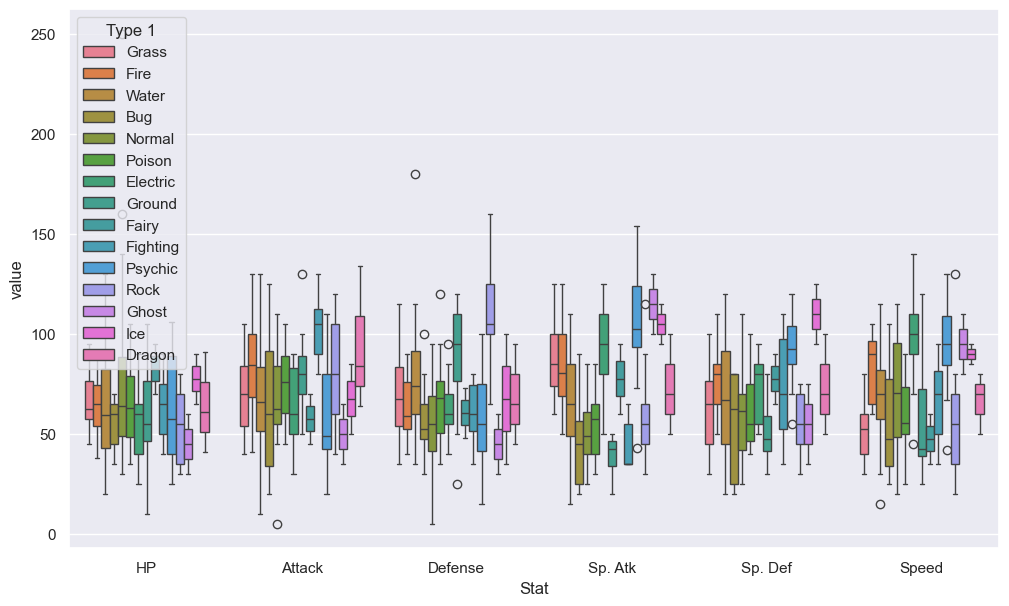

In [58]:
sns.boxplot(x='Stat', y='value', data=melted_df, 
              hue='Type 1')
plt.show()

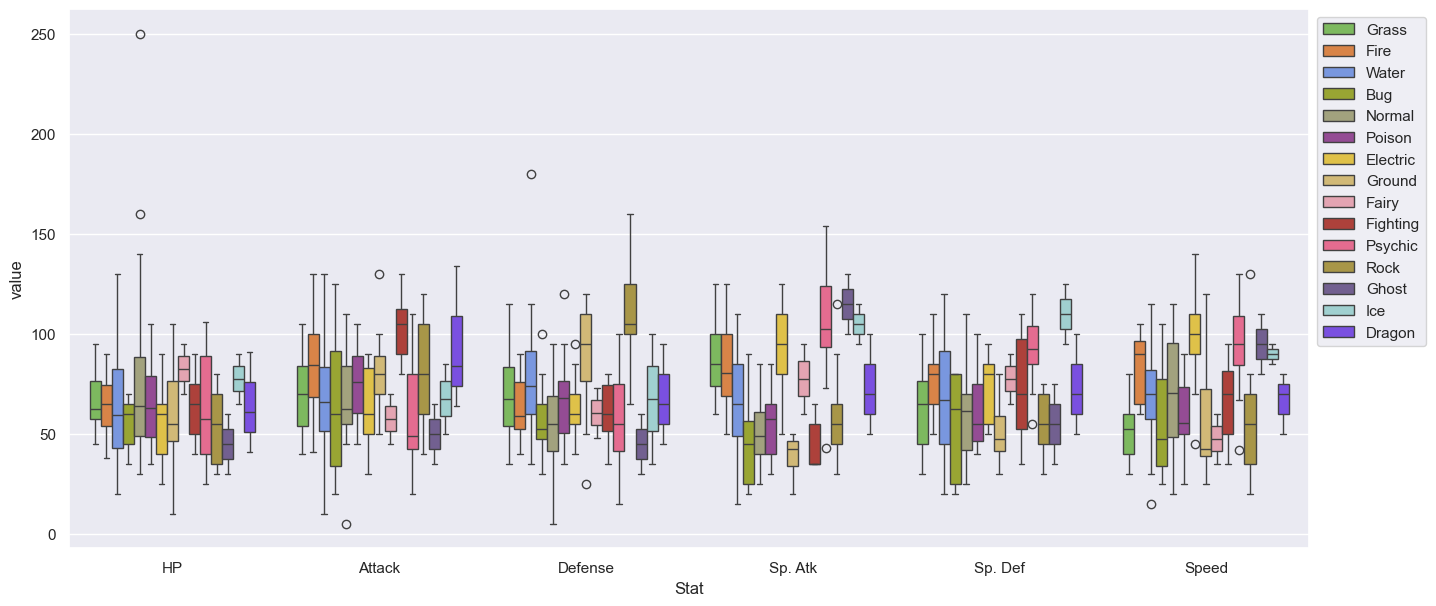

In [17]:
# powiększamy wykres
plt.figure(figsize=(16,7))
 
sns.boxplot(x='Stat', 
              y='value', 
              data=melted_df, 
              hue='Type 1', 
              palette=pkmn_type_colors) # dodajemy paletę

# przenosimy legendę
plt.legend(bbox_to_anchor=(1, 1))
plt.show()



## panele

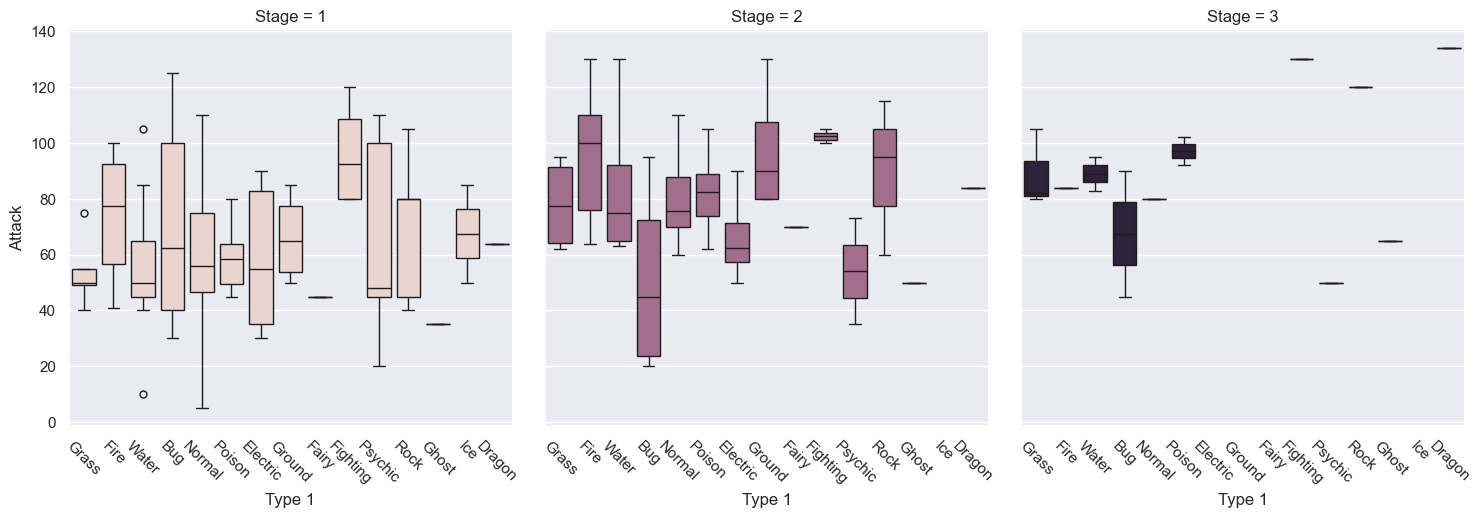

In [61]:
g = sns.catplot(x='Type 1', 
                   y='Attack', 
                   data=df, 
                   hue='Stage',  # kolor
                   col='Stage',  # podział po Stage
                   kind='box',
                   legend=False) # typ
 
g.set_xticklabels(rotation=-45)
 
plt.show()

#### **Dane opisujące zakupy**
------

Kolumny w zbiorze danych:

`Wiek` – wiek klienta wyrażony w latach 

`Płeć` – płeć klienta

`Kanał_Zakupów` – miejsce dokonywania zakupów: Online oraz Stacjonarnie

`Wydatki_PLN` – kwota, jaką klient wydał na zakupy, podana w złotówkach

`Liczba_Zakupów` – liczba zakupionych produktów

*Note*
- wykres gęstości - `kdeplot()`
- wykres punktowy z linią trendu - `regplot()`

In [19]:
df = pd.read_csv("zakupy.csv")

### Zadanie 1.1
-----


Sprwadź poniższą hipotezę.

*Osoby kupujące online wydają jednorazowo więcej niż klienci sklepów stacjonarnych.*

Text(0, 0.5, 'Gęstość')

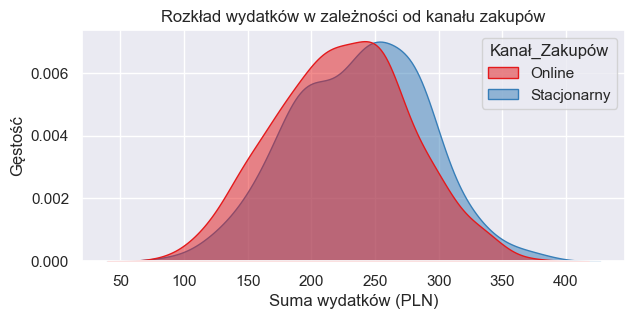

In [24]:
plt.figure(figsize=(7,3))
sns.kdeplot(data=df, x='Wydatki_PLN', hue = "Kanał_Zakupów", fill = True, common_norm=False, palette='Set1', alpha=0.5)

plt.title("Rozkład wydatków w zależności od kanału zakupów")
plt.xlabel('Suma wydatków (PLN)')
plt.ylabel('Gęstość')

### Zadanie 1.2
-----


Sprwadź poniższą hipotezę.

*Istnieje wyraźny podział: młodsi klienci wolą zakupy online, natomiast starsi wybierają sklep stacjonarny.*

<Axes: xlabel='Kanał_Zakupów', ylabel='Wiek'>

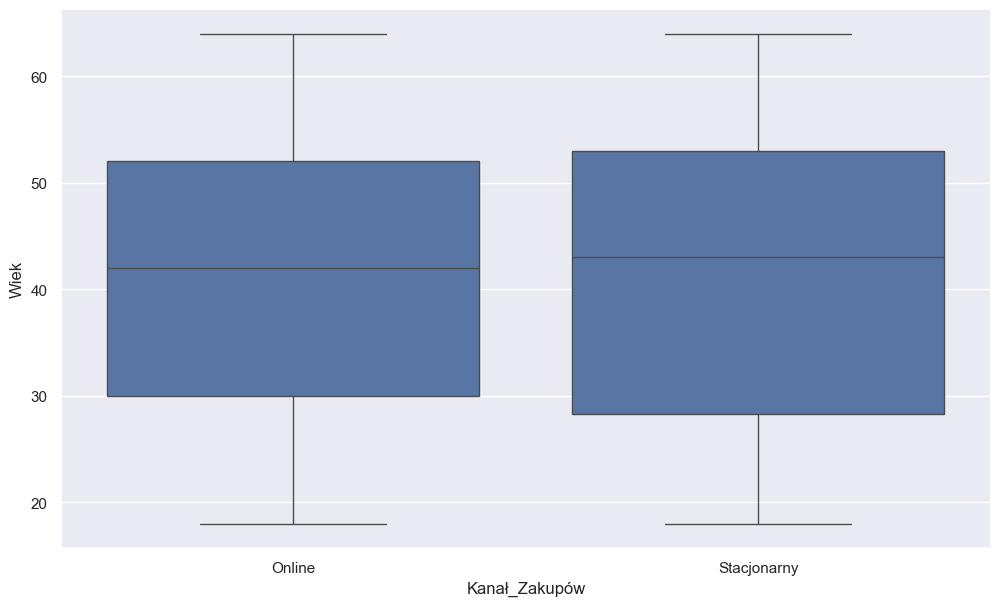

In [25]:
sns.boxplot(data=df, x = "Kanał_Zakupów", y = "Wiek")

### Zadanie 1.3
-----


Sprwadź poniższą hipotezę.

*Im więcej klient wydaje w naszym sklepie, tym większą łączną liczbę zakupów u nas zaliczył.*

<Axes: xlabel='Wydatki_PLN', ylabel='Liczba_Zakupów'>

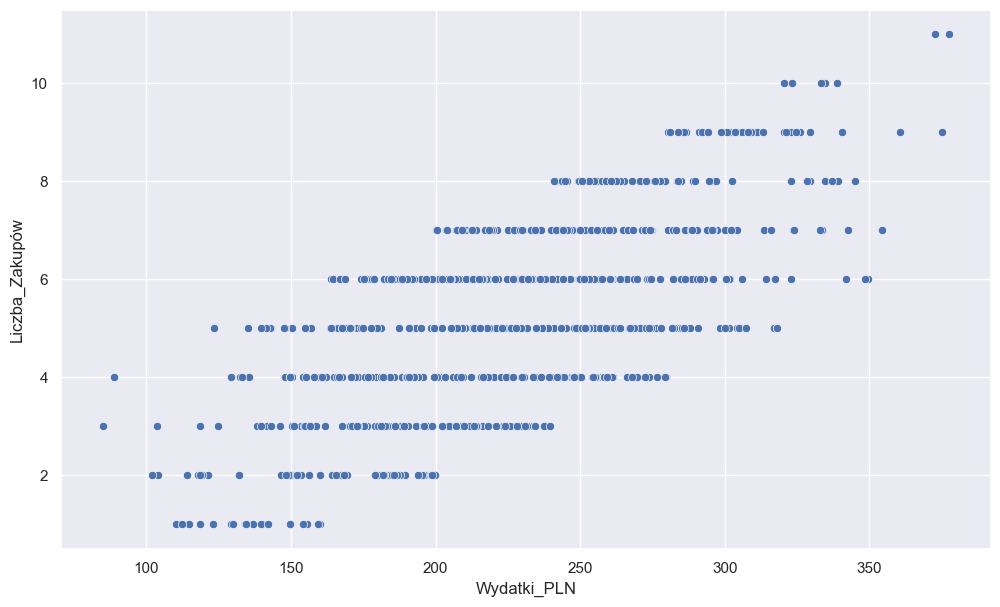

In [27]:
sns.scatterplot(data=df, x = 'Wydatki_PLN', y = 'Liczba_Zakupów')

<Axes: xlabel='Wydatki_PLN', ylabel='Liczba_Zakupów'>

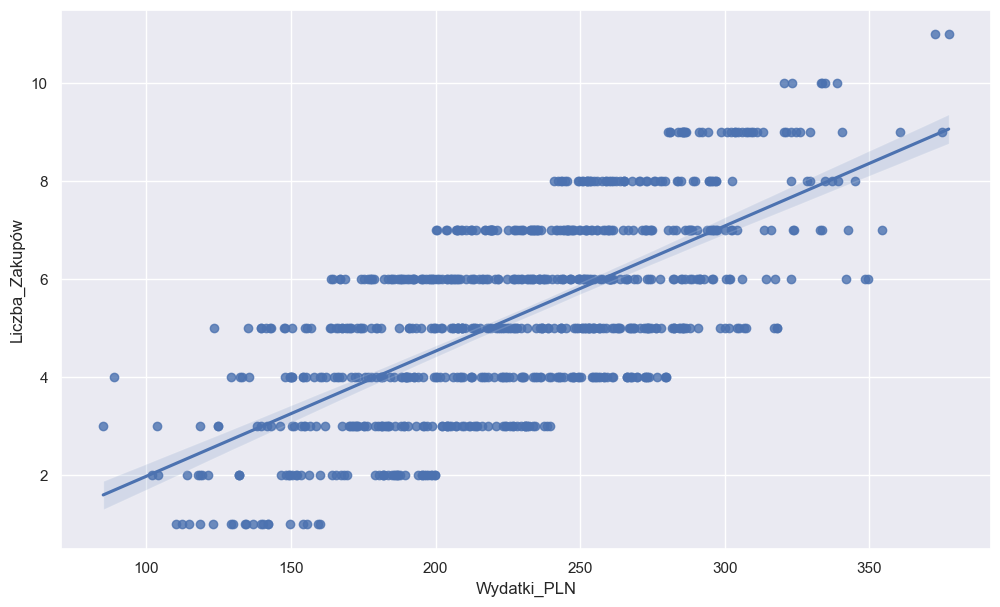

In [28]:
sns.regplot(data=df, x = 'Wydatki_PLN', y = 'Liczba_Zakupów')